In [ ]:
import os
from openai import OpenAI
import numpy as np
import math, hashlib, re, json, time, textwrap
from dataclasses import dataclass, field
from typing import List, Dict, Optional, Tuple, Any, Set, Callable
from collections import defaultdict
from datetime import datetime, timedelta
from abc import ABC, abstractmethod
import matplotlib.pyplot as plt
from copy import deepcopy

import warnings
warnings.filterwarnings("ignore")

OPENAI_API_KEY = "sk-YOUR-KEY-HERE"
os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY
client = OpenAI(api_key=OPENAI_API_KEY)

# 1) Foundations: Memory Taxonomy & Core Utilities


**Why Memory Matters**

An LLM is a stateless function: tokens in, tokens out. Every conversation starts from zero. It cannot remember that you prefer Python, that Alice is VP of Product, or that Project Phoenix launched last quarter. Without memory, an agent is an amnesiac genius — brilliant in the moment, useless over time.

**The Tulving-to-Engineering Mapping**

The field draws from Endel Tulving's 1972 taxonomy of human memory (semantic, episodic, procedural) but is rapidly developing its own vocabulary. The practical spectrum spans:

```
Simple ◄──────────────────────────────────────────────► Complex

CLAUDE.md        Mem0            Letta/MemGPT       Zep/Graphiti
(plain file)     (vector+KV+     (OS-inspired        (temporal
                  graph store)    tiered hierarchy)   knowledge graph)
```

| Human Memory | Agent Memory | Engineering Tier | Example |
|---|---|---|---|
| Episodic | What happened | Message buffer + Recall | 'Met Alice on Tuesday, discussed Phoenix' |
| Semantic | What is true | Core blocks + Archival | 'Alice is VP Product at Acme AI' |
| Procedural | How to do things | Tool defs + Prompt rules | 'To deploy: run git push hermes main' |
| Working | Current focus | Context window | Active conversation |

Modern systems add two more tiers not in Tulving:
- **Key-Value store** (Mem0): structured preferences like `{language: Python, tz: PST}`
- **Self-rewriting prompts** (LangMem): the agent edits its own system prompt based on feedback

In [ ]:
# ============================================================
# Core utilities: embedding, tokenization, similarity
# ============================================================

STOP_WORDS = frozenset(
    "a an the is are was were be been have has had do does did "
    "will would shall should may might can could of in on at to for "
    "with by from as into through during it its this that these those "
    "i me my we our you your he she they them and or but not".split()
)


def tokenize(text: str) -> List[str]:
    """Lowercase tokenize with stop-word removal."""
    return [
        t
        for t in re.findall(r"[a-z0-9]+", text.lower())
        if t not in STOP_WORDS and len(t) > 1
    ]


def build_sparse(text: str) -> Dict[str, int]:
    """Build term-frequency sparse vector for BM25."""
    tf: Dict[str, int] = defaultdict(int)
    for t in tokenize(text):
        tf[t] += 1
    return dict(tf)


def embed_texts(texts: List[str]) -> List[np.ndarray]:
    """
    Batch embed via OpenAI text-embedding-3-small.
    Returns list of (1536,) numpy arrays.
    Batching is critical: 1 API call for N texts vs N calls.
    """
    if not texts:
        return []
    resp = client.embeddings.create(input=texts, model="text-embedding-3-small")
    return [np.array(d.embedding, dtype=np.float32) for d in resp.data]


def embed_one(text: str) -> np.ndarray:
    """Embed a single text. Returns (1536,) numpy array."""
    return embed_texts([text])[0]


def cosine_sim(a: np.ndarray, b: np.ndarray) -> float:
    """Cosine similarity between two vectors."""
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-8))


def call_llm(
    system: str, user: str, schema: Optional[Dict] = None, model: str = "gpt-5-mini"
) -> str:
    """
    Unified LLM call wrapper.
    If schema is provided, uses Structured Output (json_schema).
    Otherwise returns plain text.
    """

    kwargs: Dict[str, Any] = {
        "model": model,
        "messages": [
            {"role": "system", "content": system},
            {"role": "user", "content": user},
        ],
    }

    if schema:
        kwargs["response_format"] = {
            "type": "json_schema",
            "json_schema": schema,
        }

    resp = client.chat.completions.create(**kwargs)
    return resp.choices[0].message.content.strip()


# Quick test
embs = embed_texts(["Alice VP Product", "Bob founded TechCorp"])
print(f"Embedding dim: {len(embs[0])}")
print(f"Cosine sim: {cosine_sim(embs[0], embs[1]):.4f}")
print(f'Sparse: {build_sparse("Alice is VP of Product at Acme AI")}')

Embedding dim: 1536
Cosine sim: 0.3333
Sparse: {'alice': 1, 'vp': 1, 'product': 1, 'acme': 1, 'ai': 1}


Every memory system needs a canonical entry format. Ours is designed
to be the *union* of what Mem0, Zep, GBrain, and LLM Wiki each need — the comment on each field below names the system it comes from.


In [ ]:
# ============================================================
# Core data structure: MemoryEntry
# ============================================================


@dataclass
class MemoryEntry:
    """
    Unified memory entry — the atom of every memory system.

    Design decisions (each justified by a real system):

    - Bi-temporal timestamps (Zep): separates 'when recorded' from 'when true'.
      This is critical for temporal queries: 'Who was CEO in January?'

    - Dense + sparse representations (Mem0): enables hybrid retrieval.
      Dense catches semantic similarity, sparse catches exact keywords.

    - Entity list (GBrain): every entry declares which entities it mentions.
      This auto-wires the knowledge graph — zero manual linking needed.

    - Source IDs (LLM Wiki): every derived fact traces back to its raw sources.
      This makes the memory auditable and debuggable.

    - Importance score (Mem0): multi-signal scoring for retrieval ranking.
    """

    content: str

    # 'episodic', 'semantic', 'procedural'
    memory_type: str
    memory_id: str = ""
    # GBrain: entity names auto-wire this entry into the knowledge graph
    entities: List[str] = field(default_factory=list)
    relations: List[Tuple[str, str, str]] = field(default_factory=list)
    # Mem0: dense vector for semantic search + sparse token counts for BM25 keyword search
    embedding: Optional[np.ndarray] = None
    sparse_tokens: Dict[str, int] = field(default_factory=dict)

    # Zep bi-temporal timestamps
    created_at: str = ""  # transaction time: when we recorded it
    valid_from: str = ""  # when the fact became true
    valid_until: str = ""  # when the fact stopped being true ('' = still true)

    # Scoring signals
    importance: float = 0.5
    access_count: int = 0
    # LLM Wiki provenance: raw sources this fact was derived from
    source_ids: List[str] = field(default_factory=list)
    confidence: float = 1.0
    tags: List[str] = field(default_factory=list)
    metadata: Dict[str, Any] = field(default_factory=dict)

    def __post_init__(self):
        if not self.memory_id:
            self.memory_id = hashlib.md5(
                f"{self.content}:{self.created_at}".encode()
            ).hexdigest()[:12]
        if not self.created_at:
            self.created_at = datetime.now().isoformat()


class MT:
    """Memory type constants."""

    EPISODIC = "episodic"
    SEMANTIC = "semantic"
    PROCEDURAL = "procedural"


# === Quick Demo ===
demo = MemoryEntry(
    content="Alice is VP of Product at Acme AI",
    memory_type=MT.SEMANTIC,
    entities=["Alice", "Acme AI"],
    relations=[("Alice", "works_at", "Acme AI")],
    importance=0.85,
    valid_from="2023-01-01",
    source_ids=["meeting_0042"],
)
print(f"ID={demo.memory_id} | type={demo.memory_type} | entities={demo.entities}")

ID=5b0d79bb772d | type=semantic | entities=['Alice', 'Acme AI']


# 2) Key-Value Store (Mem0 Innovation)

**Why Free-Text Isn't Enough**

Mem0's KV store handles **structured preferences** that don't belong in free text:

```
KV Store:                          vs.   Free-text Core Memory:
'preferred_language' -> 'Python'        'User prefers Python over JS'
'timezone' -> 'Asia/Singapore'          'User is in Singapore timezone'
'code_style' -> 'black formatter'       'Uses black for formatting'
```

The KV store enables **exact key lookup** (O(1)) vs semantic search (O(n)).
When the agent needs the user's timezone, it reads `kv['timezone']` directly
rather than searching through free text hoping to find it.

Mem0 writes to **three stores simultaneously** on every memory add:
vector store + graph + KV. This is the 'multi-store write' pattern.

In [ ]:
# ============================================================
# Key-Value Store — Mem0's structured preference tier
# ============================================================

# Schema for LLM-powered KV extraction
KV_EXTRACTION_SCHEMA = {
    "name": "kv_extraction",
    "strict": True,
    "schema": {
        "type": "object",
        "properties": {
            "pairs": {
                "type": "array",
                "items": {
                    "type": "object",
                    "properties": {
                        "key": {"type": "string"},
                        "value": {"type": "string"},
                        "confidence": {"type": "number"},
                    },
                    "required": ["key", "value", "confidence"],
                    "additionalProperties": False,
                },
            },
        },
        "required": ["pairs"],
        "additionalProperties": False,
    },
}


class KVMemoryStore:
    """
    Structured key-value preference store (Mem0 pattern).

    Unlike free-text memory, the KV store supports:
    - Exact key lookup: O(1) instead of embedding search
    - Type safety: values are always strings but keys are normalized
    - Versioned updates: old values are kept in history
    - LLM-powered extraction: GPT-5-mini detects preference-like
      statements and auto-extracts them as KV pairs

    The store is separate from the vector/graph stores.
    Mem0 writes to all three simultaneously on every memory add.
    """

    def __init__(self):
        # Current key-value pairs: key -> value
        self.store: Dict[str, str] = {}

        # Version history: key -> [(value, timestamp, source)]
        # Keeps track of how preferences changed over time
        self.history: Dict[str, List[Tuple[str, str, str]]] = defaultdict(list)

    def set(self, key: str, value: str, source: str = ""):
        """
        Set a key-value pair with versioning.
        If the key already exists, the old value is pushed to history
        before being overwritten. This enables temporal queries like
        'What was the preferred language before the switch?'
        """
        # Normalize key to lowercase, underscored
        key = key.strip().lower().replace(" ", "_")

        # If key exists and value is different, archive the old value
        if key in self.store and self.store[key] != value:
            self.history[key].append(
                (
                    self.store[key],
                    datetime.now().isoformat(),
                    source,
                )
            )

        self.store[key] = value

    def get(self, key: str) -> Optional[str]:
        """O(1) exact key lookup."""
        return self.store.get(key.strip().lower().replace(" ", "_"))

    def get_history(self, key: str) -> List[Tuple[str, str, str]]:
        """Get version history for a key."""
        return self.history.get(key.strip().lower().replace(" ", "_"), [])

    def extract_and_store(self, text: str, source: str = "") -> List[Dict]:
        """
        LLM-powered extraction of key-value preferences from text.

        Given: 'I prefer Python and I am in Singapore timezone'
        Extracts: [
            {key: 'preferred_language', value: 'Python', confidence: 0.95},
            {key: 'timezone', value: 'Asia/Singapore', confidence: 0.85},
        ]

        Uses GPT-5-mini with Structured Output for guaranteed valid JSON.
        Only stores pairs with confidence >= 0.7.
        """
        raw = call_llm(
            system=(
                "Extract user preferences, settings, or factual attributes as key-value pairs. "
                "Keys should be snake_case descriptors. Values should be concise. "
                "Set confidence 0.0-1.0 based on how explicitly stated the preference is. "
                "Only extract what is clearly stated, not inferred."
            ),
            user=text,
            schema=KV_EXTRACTION_SCHEMA,
        )
        try:
            result = json.loads(raw)
        except json.JSONDecodeError:
            return []

        stored = []
        for pair in result.get("pairs", []):
            # Only store high-confidence extractions
            if pair.get("confidence", 0) >= 0.7:
                self.set(pair["key"], pair["value"], source)
                stored.append(pair)
        return stored

    def to_context_string(self) -> str:
        """Format all KV pairs for inclusion in the agent's context."""
        if not self.store:
            return ""
        lines = ["=== USER PREFERENCES (KV STORE) ==="]
        for k, v in sorted(self.store.items()):
            lines.append(f"  {k}: {v}")
        return "\n".join(lines)

    def __len__(self):
        return len(self.store)


# Demo
kv = KVMemoryStore()

# Manual set
kv.set("preferred_language", "JavaScript", source="session_001")
# Overwrites, archives old
kv.set("preferred_language", "Python", source="session_042")

# LLM-powered extraction
extracted = kv.extract_and_store(
    "I live in Singapore, prefer dark mode, and use vim as my editor.",
    source="session_043",
)

print("=== KV Store ===")
print(kv.to_context_string())
print(f"\nExtracted {len(extracted)} pairs from text:")
for p in extracted:
    print(f'  {p["key"]}: {p["value"]} (conf={p["confidence"]})')
print(f'\nHistory for preferred_language: {kv.get_history("preferred_language")}')

=== KV Store ===
=== USER PREFERENCES (KV STORE) ===
  preferred_editor: vim
  preferred_language: Python
  residence_country: Singapore
  ui_theme_preference: dark

Extracted 3 pairs from text:
  residence_country: Singapore (conf=1.0)
  ui_theme_preference: dark (conf=1.0)
  preferred_editor: vim (conf=1.0)

History for preferred_language: [('JavaScript', '2026-05-08T05:33:29.105012', 'session_042')]


# 3) Tiered Memory Architecture (MemGPT/Letta Pattern)

## 3.1 The OS Analogy — In Full Detail

```
CONTEXT WINDOW (RAM) — what the LLM sees on every call:
  ┌──────────────────────────────────────────────┐
  │  System Prompt         (kernel)              │
  │  Core Memory Blocks    (CPU registers)       │  <- agent can read/write
  │  KV Preferences        (env variables)       │  <- Mem0 addition
  │  Retrieved Memories    (DMA from disk)       │  <- search results
  │  Message Buffer        (L1/L2 cache)         │  <- recent messages
  └──────────────────────────────────────────────┘

EXTERNAL STORAGE — searched on demand:
  ┌──────────────────────────────────────────────┐
  │  Recall Memory         (swap / page file)    │  <- evicted messages
  │  Archival Memory       (HDD / SSD)           │  <- long-term facts
  │  Knowledge Graph       (relational DB)       │  <- structured relations
  └──────────────────────────────────────────────┘
```

The critical MemGPT insight: the agent **controls** memory via explicit tool calls.
It is not passive RAG — the LLM *decides* what to remember, forget, and search.

In [ ]:
# ============================================================
# Tiered Memory Store — MemGPT/Letta OS hierarchy (deep version)
# ============================================================


class CoreMemoryBlock:
    """
    Core Memory: always visible in the agent's context window.

    Analogous to CPU registers — small, fast, persistent.
    The agent can modify these via tool calls (core_memory_append,
    core_memory_replace). Size is capped to prevent context overflow.

    Letta V1 uses three default blocks: 'persona', 'user', 'facts'.
    """

    def __init__(self, label: str, content: str = "", max_chars: int = 2000):
        self.label = label
        self.content = content
        self.max_chars = max_chars

    def append(self, text: str) -> bool:
        """
        Append new information if within character budget.
        Returns False if adding would exceed capacity.
        """
        if len(self.content) + len(text) > self.max_chars:
            return False
        self.content += text
        return True

    def replace(self, old: str, new: str) -> bool:
        """
        Surgically update a fact without rewriting the whole block.
        This is how the agent corrects stale information, e.g.
        replacing 'Alice works at Acme' with 'Alice moved to TechCorp'.
        """
        if old not in self.content:
            return False
        updated = self.content.replace(old, new, 1)
        if len(updated) > self.max_chars:
            return False
        self.content = updated
        return True

    def usage(self) -> float:
        """Fraction of capacity used. Helps agent decide when to prune."""
        return len(self.content) / self.max_chars


class MessageBuffer:
    """
    Message Buffer: recent conversation turns, kept in-context.

    Analogous to L1/L2 cache. When full, oldest messages are evicted
    (FIFO) and returned to RecallMemory — this is the 'page fault'.
    Conversation history is never lost, just moved to a slower tier.
    """

    def __init__(self, max_msg: int = 20):
        self.msgs: List[Dict] = []
        self.max_msg = max_msg

    def add(self, role: str, content: str) -> List[Dict]:
        """Add message; return any evicted messages for archival."""
        self.msgs.append(
            {
                "role": role,
                "content": content,
                "ts": datetime.now().isoformat(),
            }
        )
        # FIFO eviction — oldest messages are 'paged out'
        evicted = []
        while len(self.msgs) > self.max_msg:
            evicted.append(self.msgs.pop(0))
        return evicted


class RecallMemory:
    """
    Recall Memory: searchable archive of evicted conversation history.

    Analogous to swap/page file. The agent searches this via
    'conversation_search' to find things said earlier.
    Uses OpenAI embeddings for semantic retrieval.
    """

    def __init__(self):
        self.entries: List[MemoryEntry] = []

    def store(self, messages: List[Dict]):
        """Batch-embed and archive evicted messages."""
        if not messages:
            return
        texts = [m["content"] for m in messages]
        # Single batch API call
        embs = embed_texts(texts)

        for msg, emb in zip(messages, embs):
            self.entries.append(
                MemoryEntry(
                    content=f"[{msg['role']}]: {msg['content']}",
                    memory_type=MT.EPISODIC,
                    created_at=msg.get("ts", ""),
                    sparse_tokens=build_sparse(msg["content"]),
                    embedding=emb,
                )
            )

    def search(self, query: str, top_k: int = 5) -> List[MemoryEntry]:
        """Semantic search via cosine similarity."""
        if not self.entries:
            return []
        qe = embed_one(query)

        scored = [
            (cosine_sim(qe, e.embedding), e)
            for e in self.entries
            if e.embedding is not None
        ]
        scored.sort(key=lambda x: x[0], reverse=True)

        return [e for _, e in scored[:top_k]]


class ArchivalMemory:
    """
    Archival Memory: long-term persistent knowledge store.

    Analogous to disk. Holds semantic facts and procedural knowledge.
    Uses hybrid retrieval: 70% dense (semantic) + 30% sparse (keyword).
    This mirrors Mem0's multi-signal scoring — vector search catches
    conceptual matches, keyword search catches exact phrases.
    """

    def __init__(self):
        self.entries: List[MemoryEntry] = []

    def insert(self, entry: MemoryEntry):
        """Store a new memory. Lazily computes embedding if needed."""
        if entry.embedding is None:
            entry.embedding = embed_one(entry.content)
        if not entry.sparse_tokens:
            entry.sparse_tokens = build_sparse(entry.content)
        self.entries.append(entry)

    def search(self, query: str, top_k: int = 5) -> List[MemoryEntry]:
        """Hybrid: 0.7*cosine + 0.3*keyword_overlap."""
        if not self.entries:
            return []
        qe = embed_one(query)
        qs = build_sparse(query)
        scored = []
        for e in self.entries:
            # Dense score: semantic similarity via OpenAI embeddings
            d = cosine_sim(qe, e.embedding) if e.embedding is not None else 0
            # Sparse score: fraction of query keywords found in entry
            s = len(set(qs) & set(e.sparse_tokens)) / max(len(qs), 1) if qs else 0
            scored.append((0.7 * d + 0.3 * s, e))
        scored.sort(key=lambda x: x[0], reverse=True)
        return [e for _, e in scored[:top_k]]


class TieredMemory:
    """
    Complete MemGPT/Letta + Mem0 memory hierarchy.

    Context window (always visible):
      Core blocks (registers) + KV store (env vars) + Buffer (cache)
    External storage (searched on demand):
      Recall (swap) + Archival (disk)
    """

    def __init__(self, buf_size: int = 10):
        self.core = {
            "persona": CoreMemoryBlock("persona", "I am a helpful AI assistant."),
            "user": CoreMemoryBlock("user"),
            "facts": CoreMemoryBlock("facts"),
        }
        self.kv = KVMemoryStore()  # Mem0 addition: structured preferences
        self.buffer = MessageBuffer(buf_size)
        self.recall = RecallMemory()
        self.archival = ArchivalMemory()

    def process(self, role: str, content: str):
        """Process message: buffer it, evict overflow to recall."""
        evicted = self.buffer.add(role, content)
        if evicted:
            self.recall.store(evicted)

    def assemble(self, query: str, max_r: int = 3, max_a: int = 3) -> str:
        """
        Assemble full context from all tiers (Letta pattern).
        This string becomes the system context the LLM sees.

        Order matters — highest priority first:
          1. Core blocks (always present)
          2. KV preferences (always present)
          3. Recalled conversations (searched)
          4. Archival knowledge (searched)
          5. Recent messages (chronological)
        """
        parts = ["=== CORE MEMORY ==="]
        for n, b in self.core.items():
            if b.content:
                parts.append(f"  [{n}]: {b.content}")

        # KV store — Mem0's structured preference tier
        kv_str = self.kv.to_context_string()
        if kv_str:
            parts.append(kv_str)

        rr = self.recall.search(query, max_r)
        if rr:
            parts.append("\n=== RECALLED CONVERSATIONS ===")
            for m in rr:
                parts.append(f"  {m.content}")

        ar = self.archival.search(query, max_a)
        if ar:
            parts.append("\n=== ARCHIVAL KNOWLEDGE ===")
            for m in ar:
                parts.append(f"  [{m.memory_type}] {m.content}")

        parts.append("\n=== RECENT CONVERSATION ===")
        for m in self.buffer.msgs:
            parts.append(f"  [{m['role']}]: {m['content']}")

        return "\n".join(parts)

    def stats(self):
        return {
            "core": {k: f"{v.usage():.0%}" for k, v in self.core.items()},
            "kv_pairs": len(self.kv),
            "buffer": len(self.buffer.msgs),
            "recall": len(self.recall.entries),
            "archival": len(self.archival.entries),
        }


# Demo
mem = TieredMemory(buf_size=5)
mem.core["user"].append("\nName: Alice\nRole: VP Product at Acme AI")
mem.kv.set("preferred_language", "Python")
mem.kv.set("timezone", "Asia/Singapore")
mem.archival.insert(
    MemoryEntry(
        content="Project Phoenix is a transformer recommendation engine at Acme AI",
        memory_type=MT.SEMANTIC,
        entities=["Phoenix", "Acme AI"],
        importance=0.9,
    )
)

for r, c in [
    ("user", "Hi I am Alice VP at Acme AI"),
    ("assistant", "Nice to meet you"),
    ("user", "Working on Project Phoenix"),
    ("assistant", "Got it"),
    ("user", "Custom attention mechanisms"),
    ("assistant", "Interesting"),
    ("user", "I prefer dark mode"),
    ("assistant", "Noted"),
]:
    mem.process(r, c)
print(mem.assemble("What project is Alice on?")[:600])
print(f"\nStats: {mem.stats()}")

=== CORE MEMORY ===
  [persona]: I am a helpful AI assistant.
  [user]: 
Name: Alice
Role: VP Product at Acme AI
=== USER PREFERENCES (KV STORE) ===
  preferred_language: Python
  timezone: Asia/Singapore

=== RECALLED CONVERSATIONS ===
  [user]: Hi I am Alice VP at Acme AI
  [user]: Working on Project Phoenix
  [assistant]: Nice to meet you

=== ARCHIVAL KNOWLEDGE ===
  [semantic] Project Phoenix is a transformer recommendation engine at Acme AI

=== RECENT CONVERSATION ===
  [assistant]: Got it
  [user]: Custom attention mechanisms
  [assistant]: Interesting
  [user]: I prefer dark mode
  [a

Stats: {'core': {'persona': '1%', 'user': '2%', 'facts': '0%'}, 'kv_pairs': 2, 'buffer': 5, 'recall': 3, 'archival': 1}


# 4) Temporal Knowledge Graph (Zep/Graphiti Pattern)

**Why Bi-Temporal Matters**

Standard KGs record facts without time. But facts change:
- Alice **was** VP at Acme (2023-2026), **now** CEO at TechCorp
- Bob **was** CTO, **now** retired

Zep's Graphiti uses **two time dimensions** per edge:
- `valid_from / valid_until`: when the relationship holds **in reality**
- `recorded_at / invalidated_at`: when it was **recorded/superseded in the graph**

This enables: 'Who was CEO **in January**?' even after the CEO changes.

In [ ]:
# ============================================================
# Temporal Knowledge Graph — Zep/Graphiti core
# ============================================================


@dataclass
class GNode:
    """Entity node in the knowledge graph."""

    nid: str
    name: str
    ntype: str  # 'person', 'company', 'project', 'concept'
    props: Dict = field(default_factory=dict)
    emb: Optional[np.ndarray] = None


@dataclass
class GEdge:
    """
    Bi-temporal edge (Zep's core innovation).

    Two timelines:
    - valid_from/until: when the relationship holds in reality
      Example: Alice works_at Acme from 2023-01 to 2026-04
    - recorded_at: when we recorded this edge (transaction time)
    - invalidated: when this edge was superseded by newer info
      Note: invalidated edges are NOT deleted — they become
      historical, queryable with temporal filters.
    """

    eid: str
    src: str
    tgt: str
    # 'works_at', 'founded', 'invested_in', etc.
    rel: str
    valid_from: str = ""
    valid_until: str = ""
    recorded_at: str = field(default_factory=lambda: datetime.now().isoformat())
    invalidated: str = ""
    # which episode/source created this edge
    episode: str = ""
    confidence: float = 1.0

    def is_valid_at(self, ts: str) -> bool:
        """Check if this edge was true at a given point in time."""
        if self.valid_from and ts < self.valid_from:
            return False
        if self.valid_until and ts > self.valid_until:
            return False
        return not self.invalidated


class TempKG:
    """
    Temporal Knowledge Graph with:
    - Entity resolution (deduplication via name normalization)
    - Bi-temporal edges (Zep pattern)
    - Edge invalidation (soft delete for temporal queries)
    - BFS traversal with type filtering + cycle prevention
    - Semantic search over node embeddings
    """

    def __init__(self):
        self.nodes: Dict[str, GNode] = {}
        self.edges: Dict[str, GEdge] = {}
        self.e_src: Dict[str, List[str]] = defaultdict(list)
        self.e_tgt: Dict[str, List[str]] = defaultdict(list)
        self.e_type: Dict[str, List[str]] = defaultdict(list)
        self.n_type: Dict[str, List[str]] = defaultdict(list)
        # Entity resolution index: normalized_name -> node_id
        self.name2id: Dict[str, str] = {}

    def _gid(self, pfx, s):
        return f"{pfx}_{hashlib.md5(s.encode()).hexdigest()[:8]}"

    def add_node(self, name: str, ntype: str, **p) -> GNode:
        """
        Add or resolve an entity node.

        Entity resolution: if 'alice' already exists, merge instead
        of creating 'Alice' as a separate node. This is GBrain's
        reconciliation pattern — prevents duplicate entities.
        """
        k = name.strip().lower()
        if k in self.name2id:
            existing = self.nodes[self.name2id[k]]
            existing.props.update(p)
            return existing
        nid = self._gid("n", f"{name}:{ntype}")
        n = GNode(nid, name, ntype, p, emb=embed_one(f"{name} ({ntype})"))
        self.nodes[nid] = n
        self.name2id[k] = nid
        self.n_type[ntype].append(nid)
        return n

    def add_edge(
        self,
        sn="Alice",
        tn="TSLA",
        rel="works_at",
        st="person",
        tt="company",
        # valid from
        vf="",
        # valid until
        vu="",
        # episode
        ep="",
    ) -> GEdge:
        """
        Add a typed edge with bi-temporal timestamps.

        Edge deduplication: if (Alice, works_at, Acme) already exists
        and isn't invalidated, update it rather than creating a duplicate.
        This prevents the graph from accumulating redundant edges.
        """

        # source node & target node
        s, t = self.add_node(sn, st), self.add_node(tn, tt)

        # Dedup check
        for eid in self.e_src.get(s.nid, []):
            e = self.edges[eid]
            if e.tgt == t.nid and e.rel == rel and not e.invalidated:
                if vu:
                    e.valid_until = vu
                return e

        eid = self._gid("e", f"{s.nid}:{t.nid}:{rel}")
        edge = GEdge(eid, s.nid, t.nid, rel, vf, vu, episode=ep)
        self.edges[eid] = edge
        self.e_src[s.nid].append(eid)
        self.e_tgt[t.nid].append(eid)
        self.e_type[rel].append(eid)
        return edge

    def invalidate(self, eid: str):
        """
        Soft-delete an edge by marking it as invalidated.
        The edge remains queryable for temporal history.
        """
        if eid in self.edges:
            self.edges[eid].invalidated = datetime.now().isoformat()

    def traverse(
        self,
        start: str,
        max_d: int = 2,
        rels=None,
        direction="both",
        valid_at: str = "",
    ) -> List[Tuple[GNode, GEdge, int]]:
        """
        BFS traversal with:
        - Cycle prevention (visited set)
        - Relation type filtering (only follow specific edge types)
        - Temporal filtering (only follow edges valid at a given time)
        - Directional control (outgoing, incoming, or both)
        """
        visited, results, q = {start}, [], [(start, 0)]

        while q:
            cur, d = q.pop(0)

            if d >= max_d:
                continue

            eids = []

            if direction in ("out", "both"):
                eids += self.e_src.get(cur, [])

            if direction in ("in", "both"):
                eids += self.e_tgt.get(cur, [])

            for eid in eids:
                e = self.edges[eid]

                if rels and e.rel not in rels:
                    continue

                if e.invalidated:
                    continue

                if valid_at and not e.is_valid_at(valid_at):
                    continue

                nbr = e.tgt if e.src == cur else e.src

                if nbr not in visited:
                    visited.add(nbr)
                    n = self.nodes.get(nbr)
                    if n:
                        results.append((n, e, d + 1))
                        q.append((nbr, d + 1))
        return results

    def sem_search(self, query: str, top_k=5):
        """OpenAI embedding search over entity nodes."""
        qe = embed_one(query)
        # Note: n.emb = embed_one(f'{name} ({ntype})')
        sc = [
            (n, cosine_sim(qe, n.emb)) for n in self.nodes.values() if n.emb is not None
        ]
        sc.sort(key=lambda x: x[1], reverse=True)
        return sc[:top_k]

    def get_temporal_snapshot(self, entity_name: str, at_time: str) -> List[GEdge]:
        """
        Temporal query: what edges were valid for this entity at time T?
        This is Zep's killer feature — point-in-time entity state.
        """
        nid = self.name2id.get(entity_name.strip().lower())
        if not nid:
            return []
        valid_edges = []

        for eid in self.e_src.get(nid, []) + self.e_tgt.get(nid, []):
            e = self.edges[eid]
            if e.is_valid_at(at_time):
                valid_edges.append(e)
        return valid_edges

    def stats(self):
        active = sum(1 for e in self.edges.values() if not e.invalidated)
        return {
            "nodes": len(self.nodes),
            "edges": len(self.edges),
            "active_edges": active,
            "node_types": {k: len(v) for k, v in self.n_type.items()},
        }


# Demo
kg = TempKG()
kg.add_edge("Alice", "Acme AI", "works_at", "person", "company", vf="2023-01")
kg.add_edge("Alice", "Project Phoenix", "leads", "person", "project")
kg.add_edge("Bob", "Acme AI", "works_at", "person", "company")
kg.add_edge(
    "Bob", "TechCorp", "founded", "person", "company", vf="2018-01", vu="2022-01"
)
kg.add_edge("Carol", "Acme AI", "invested_in", "person", "company")

aid = kg.name2id.get("alice")
if aid:
    print("=== Alice graph (depth<=2) ===")
    for n, e, d in kg.traverse(aid):
        print(f"{'  '*d}-> [{e.rel}] {n.name}")

# Temporal query: what was true for Bob in 2020?
print("\n=== Bob in 2020 ===")
for e in kg.get_temporal_snapshot("Bob", "2020-06-01"):
    tgt = kg.nodes.get(e.tgt)
    print(f"  Bob --[{e.rel}]--> {tgt.name if tgt else e.tgt}")

print(f"\nGraph: {kg.stats()}")

=== Alice graph (depth<=2) ===
  -> [works_at] Acme AI
  -> [leads] Project Phoenix
    -> [works_at] Bob
    -> [invested_in] Carol

=== Bob in 2020 ===
  Bob --[works_at]--> Acme AI
  Bob --[founded]--> TechCorp

Graph: {'nodes': 6, 'edges': 5, 'active_edges': 5, 'node_types': {'person': 3, 'company': 2, 'project': 1}}


# 5) Entity Extraction (GBrain Two-Layer Pattern)

GBrain's key insight: **deterministic regex first, LLM fallback second**.

- Regex: zero cost, 87% accuracy, handles standard patterns like 'CEO of X'
- LLM: ~$0.001 per call, catches complex cases regex misses

The 'fail-improve loop': every time the LLM fallback fires, the result
is used to generate better regex patterns for next time.

In [ ]:
# ============================================================
# Entity + Relation extraction: regex first, LLM fallback
# ============================================================

# JSON schema for LLM extraction (Structured Output for gpt-5-mini)
EXTRACTION_SCHEMA = {
    "name": "extraction",
    "strict": True,
    "schema": {
        "type": "object",
        "properties": {
            "entities": {
                "type": "array",
                "items": {
                    "type": "object",
                    "properties": {
                        "name": {"type": "string"},
                        "type": {"type": "string"},
                    },
                    "required": ["name", "type"],
                    "additionalProperties": False,
                },
            },
            "relations": {
                "type": "array",
                "items": {
                    "type": "object",
                    "properties": {
                        "source": {"type": "string"},
                        "relation": {"type": "string"},
                        "target": {"type": "string"},
                    },
                    "required": ["source", "relation", "target"],
                    "additionalProperties": False,
                },
            },
        },
        "required": ["entities", "relations"],
        "additionalProperties": False,
    },
}

# Deterministic regex patterns (GBrain's 87% accuracy tier)
REGEX_PATTERNS = [
    (
        r"(\b[A-Z][a-z]+(?:\s[A-Z][a-z]+)*)\s*,?\s*(?:CEO|CTO|VP|Director|Head|President)\s+(?:of|at)\s+(\b[A-Z][a-z]+(?:\s[A-Z][a-z]+)*)",
        "works_at",
    ),
    (
        r"(\b[A-Z][a-z]+(?:\s[A-Z][a-z]+)*)\s+(?:joined|works at|works for)\s+(\b[A-Z][a-z]+(?:\s[A-Z][a-z]+)*)",
        "works_at",
    ),
    (
        r"(\b[A-Z][a-z]+(?:\s[A-Z][a-z]+)*)\s+(?:founded|co-founded)\s+(\b[A-Z][a-z]+(?:\s[A-Z][a-z]+)*)",
        "founded",
    ),
    (
        r"(\b[A-Z][a-z]+(?:\s[A-Z][a-z]+)*)\s+(?:invested in|backed)\s+(\b[A-Z][a-z]+(?:\s[A-Z][a-z]+)*)",
        "invested_in",
    ),
    (
        r"(\b[A-Z][a-z]+(?:\s[A-Z][a-z]+)*)\s+(?:advises|advisor to)\s+(\b[A-Z][a-z]+(?:\s[A-Z][a-z]+)*)",
        "advises",
    ),
]
FP = {
    "The",
    "This",
    "That",
    "What",
    "When",
    "Where",
    "How",
    "Who",
    "Which",
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
}


def regex_extract(text: str) -> Dict[str, Any]:
    """Deterministic extraction — zero LLM cost, ~87% accuracy."""
    rels, seen = [], set()
    for pat, rt in REGEX_PATTERNS:
        for m in re.finditer(pat, text):
            s, t = m.group(1), m.group(2)
            if (s, rt, t) not in seen:
                seen.add((s, rt, t))
                rels.append({"source": s, "relation": rt, "target": t})
    ents = [
        {"name": e, "type": "person"}
        for e in set(re.findall(r"\b([A-Z][a-z]+(?:\s[A-Z][a-z]+)*)\b", text)) - FP
    ]
    return {"entities": ents, "relations": rels}


def llm_extract(text: str) -> Dict[str, Any]:
    """LLM fallback — handles complex cases regex misses."""
    raw = call_llm(
        system="""
            Extract entities and relations from text. Entity types: person, company, project, concept. \
            Relation types: works_at, founded, invested_in, leads, advises, collaborates. \
            Only extract explicit facts.
            """,
        user=text,
        schema=EXTRACTION_SCHEMA,
    )
    try:
        return json.loads(raw)
    except:
        return {"entities": [], "relations": []}


def extract(text: str, use_llm: bool = True) -> Dict[str, Any]:
    """Two-layer extraction: regex first, LLM fallback if regex finds nothing."""
    result = regex_extract(text)
    if not result["relations"] and use_llm:
        result = llm_extract(text)
    return result


# Demo: compare
for t in [
    "Alice, CEO of Acme AI, announced Bob joined as CTO.",
    "The team discussed transformer architectures for recommendations.",
]:
    rx = regex_extract(t)
    lm = llm_extract(t)
    print(f'"{t[:55]}..."')
    print(f'  Regex: {[r["relation"] for r in rx["relations"]]}')
    print(f'  LLM:   {[r["relation"] for r in lm["relations"]]}\n')

"Alice, CEO of Acme AI, announced Bob joined as CTO...."
  Regex: ['works_at']
  LLM:   ['leads', 'works_at']

"The team discussed transformer architectures for recomm..."
  Regex: []
  LLM:   []



# 6) Hybrid Retrieval: BM25 + Vector + Graph + RRF

**Why Hybrid Beats Any Single Signal**

| Query | Vector wins | BM25 wins | Graph wins |
|---|---|---|---|
| 'recommendation engine' | Matches 'suggestion system' | Matches exact keyword | - |
| 'VP of Product' | - | Matches 'VP' exactly | - |
| 'Who works with Alice?' | - | - | Traverses Alice's edges |


RRF formula: `score(d) = SUM weight_i / (60 + rank_i(d))`

No normalization needed — ranks from different systems are naturally comparable.

In [ ]:
# ============================================================
# BM25 (from scratch) + RRF + Hybrid Retriever
# ============================================================


class BM25:
    """
    Okapi BM25 index — the standard sparse retrieval algorithm.

    Key formula per document d for query q:
      score(d,q) = SUM_t IDF(t) * tf(t,d) * (k1+1) / (tf(t,d) + k1*(1-b+b*dl/avgdl))

    Where:
      IDF(t)  = log((N - df(t) + 0.5) / (df(t) + 0.5) + 1)
      tf(t,d) = term frequency of t in document d
      dl       = document length, avgdl = average doc length
      k1=1.5, b=0.75 are standard tuning parameters
    """

    def __init__(self, k1=1.5, b=0.75):
        self.k1, self.b = k1, b
        self.docs: List[Tuple[str, Dict[str, int]]] = []
        # document frequency per term
        self.df: Dict[str, int] = defaultdict(int)
        # average document length
        self.avg_dl = 0.0
        # total documents
        self.N = 0

    def add(self, doc_id: str, toks: Dict[str, int]):
        """Index a document by its term-frequency representation."""
        self.docs.append((doc_id, toks))
        for t in toks:
            self.df[t] += 1
        self.N += 1

        # average document length
        self.avg_dl = sum(sum(d[1].values()) for d in self.docs) / max(self.N, 1)

    def search(self, query_toks: Dict[str, int], top_k=10):
        """BM25 ranking. Returns [(doc_id, score)] sorted descending."""

        scores = []

        for did, dt in self.docs:
            s = 0.0
            dl = sum(dt.values())

            for t in query_toks:
                if t in dt:
                    tf = dt[t]
                    df = self.df.get(t, 0)

                    # IDF: penalize common terms, boost rare terms
                    idf = math.log((self.N - df + 0.5) / (df + 0.5) + 1)

                    # TF with length normalization: longer docs get penalized
                    tf_norm = (tf * (self.k1 + 1)) / (
                        tf + self.k1 * (1 - self.b + self.b * dl / max(self.avg_dl, 1))
                    )
                    s += idf * tf_norm

            if s > 0:
                scores.append((did, s))
        scores.sort(key=lambda x: x[1], reverse=True)
        return scores[:top_k]


def rrf(
    lists: List[List[Tuple[str, float]]], k: int = 60, weights=None
) -> List[Tuple[str, float]]:
    """
    Reciprocal Rank Fusion — merges ranked lists without score normalization.
    Formula: score(d) = SUM weight_i / (k + rank_i(d))
    Standard k=60 prevents division by tiny numbers.
    """
    if not weights:
        weights = [1.0] * len(lists)
    sc = defaultdict(float)
    for w, rl in zip(weights, lists):
        for rank, (did, _) in enumerate(rl, 1):
            sc[did] += w / (k + rank)
    return sorted(sc.items(), key=lambda x: x[1], reverse=True)


class HybridRetriever:
    """
    Full hybrid retrieval pipeline (Mem0 + GBrain + Zep combined):

    Three retrieval signals:
      1. Dense vector search via OpenAI embeddings (semantic meaning)
      2. BM25 sparse search (exact keyword matching)
      3. Graph traversal boost (relational structure)

    Fused via RRF, then reranked by importance + recency (Mem0 pattern).
    """

    def __init__(self, kg: TempKG):
        self.kg = kg
        self.bm25 = BM25()
        self.entries: Dict[str, MemoryEntry] = {}

    def index(self, entry: MemoryEntry):
        """Add to all retrieval indexes simultaneously (Mem0 multi-store write)."""
        if entry.embedding is None:
            entry.embedding = embed_one(entry.content)
        if not entry.sparse_tokens:
            entry.sparse_tokens = build_sparse(entry.content)
        self.entries[entry.memory_id] = entry
        self.bm25.add(entry.memory_id, entry.sparse_tokens)

    def _vec(self, q, k=10):
        """Signal 1: dense semantic search."""
        qe = embed_one(q)
        sc = [
            (mid, cosine_sim(qe, e.embedding))
            for mid, e in self.entries.items()
            if e.embedding is not None
        ]
        sc.sort(key=lambda x: x[1], reverse=True)
        return sc[:k]

    def _bm(self, q, k=10):
        """Signal 2: sparse keyword search."""
        return self.bm25.search(build_sparse(q), k)

    def _graph(self, q, k=10):
        """Signal 3: graph-enhanced search — boost memories connected to query entities."""
        hits = self.kg.sem_search(q, 3)
        names = set()
        for n, _ in hits:
            for cn, ce, cd in self.kg.traverse(n.nid, 2):
                names.add(cn.name.lower())
        sc = [
            (mid, sum(1 for e in entry.entities if e.lower() in names) * 0.3)
            for mid, entry in self.entries.items()
            if any(e.lower() in names for e in entry.entities)
        ]
        sc.sort(key=lambda x: x[1], reverse=True)
        return sc[:k]

    def search(self, q: str, top_k=5, weights=None):
        """Full pipeline: 3 signals -> RRF -> importance rerank."""
        if not weights:
            weights = [1.0, 0.8, 1.2]
        merged = rrf(
            [
                self._vec(q, top_k * 2),
                self._bm(q, top_k * 2),
                self._graph(q, top_k * 2),
            ],
            weights=weights,
        )
        out = []
        for mid, score in merged[:top_k]:
            e = self.entries.get(mid)
            if e:
                e.access_count += 1
                out.append((e, score + e.importance * 0.1))
        out.sort(key=lambda x: x[1], reverse=True)
        return out


# Demo
ret = HybridRetriever(kg)
for m in [
    MemoryEntry(
        content="Alice VP Product at Acme AI leads Project Phoenix",
        memory_type="semantic",
        entities=["Alice", "Acme AI", "Project Phoenix"],
        importance=0.9,
    ),
    MemoryEntry(
        content="Bob CTO Acme AI formerly TechCorp",
        memory_type="semantic",
        entities=["Bob", "Acme AI", "TechCorp"],
        importance=0.85,
    ),
    MemoryEntry(
        content="Project Phoenix transformer recommendation engine",
        memory_type="semantic",
        entities=["Project Phoenix"],
        importance=0.8,
    ),
]:
    ret.index(m)

for q in ["Who works at Acme?", "recommendation engine project"]:
    print(f'\nQuery: "{q}"')
    for e, s in ret.search(q, 3):
        print(f"  [{s:.4f}] {e.content[:60]}")


Query: "Who works at Acme?"
  [0.1387] Alice VP Product at Acme AI leads Project Phoenix
  [0.1339] Bob CTO Acme AI formerly TechCorp
  [0.1149] Project Phoenix transformer recommendation engine

Query: "recommendation engine project"
  [0.1387] Alice VP Product at Acme AI leads Project Phoenix
  [0.1286] Project Phoenix transformer recommendation engine
  [0.1202] Bob CTO Acme AI formerly TechCorp


# 7) LLM-Powered Consolidation (Dream Cycle)

GBrain's 'dream cycle' / LLM Wiki's 'lint': a periodic consolidation pass.

1. **Cluster** related episodic memories by embedding similarity
2. **Summarize** each cluster via GPT-5-mini into 'compiled truth'
3. **Store** as new semantic entries with boosted importance
4. **Prune** redundant low-scored entries

In [ ]:
# ============================================================
# Memory Consolidation with LLM summarization
# ============================================================


def llm_consolidate(memories: List[MemoryEntry]) -> str:
    """Use GPT-5-mini to summarize episodic cluster into compiled truth."""
    texts = "\n".join(f"- {m.content}" for m in memories)
    return call_llm(
        system="You are a memory consolidation engine. Given multiple episodic memories about the same topic, produce a single concise factual summary. Include only confirmed facts. One paragraph.",
        user=f"Consolidate:\n{texts}",
    )


class Consolidator:
    """
    Sleep-time consolidation engine.
    Clusters episodes -> LLM summarize -> semantic entries -> prune.
    Decay model: recency = 0.995 ^ hours_elapsed (Hong & He 2025).
    """

    def __init__(self, decay=0.995, thresh=0.7):
        self.decay, self.thresh = decay, thresh

    def score(self, e, now):
        """Composite: 0.4*recency + 0.4*importance + 0.2*access_freq."""
        try:
            h = (now - datetime.fromisoformat(e.created_at)).total_seconds() / 3600
            rec = self.decay**h
        except:
            rec = 0.5
        return 0.4 * rec + 0.4 * e.importance + 0.2 * min(e.access_count / 10, 1)

    def cluster(self, mems):
        """Greedy clustering by OpenAI embedding similarity."""
        if not mems:
            return []
        embs = embed_texts([m.content for m in mems])
        for m, emb in zip(mems, embs):
            if m.embedding is None:
                m.embedding = emb
        clusters, centroids = [], []
        for i, emb in enumerate(embs):
            bc, bs = -1, -1.0
            for j, c in enumerate(centroids):
                s = cosine_sim(emb, c)
                if s > bs:
                    bs, bc = s, j
            if bs >= self.thresh and bc >= 0:
                clusters[bc].append(i)
                n = len(clusters[bc])
                centroids[bc] = (centroids[bc] * (n - 1) + emb) / n
            else:
                clusters.append([i])
                centroids.append(emb.copy())
        return [[mems[i] for i in cl] for cl in clusters]

    def consolidate(self, episodes, now=None):
        if now is None:
            now = datetime.now()
        clusters = self.cluster(episodes)
        new_sem, prune = [], []
        for cl in clusters:
            if len(cl) < 2:
                continue
            compiled = llm_consolidate(cl)
            all_ents = set()
            for m in cl:
                all_ents.update(m.entities)
            scored = sorted(
                [(m, self.score(m, now)) for m in cl], key=lambda x: x[1], reverse=True
            )
            new_sem.append(
                MemoryEntry(
                    content=compiled,
                    memory_type=MT.SEMANTIC,
                    entities=list(all_ents),
                    importance=min(scored[0][0].importance + 0.1, 1),
                    confidence=min(len(cl) / 5, 1),
                    tags=["consolidated"],
                )
            )
            for m, s in scored[1:]:
                if s < 0.3:
                    prune.append(m.memory_id)
        return {"new": new_sem, "prune": prune, "clusters": len(clusters)}


# Demo
con = Consolidator()
bt = datetime(2026, 1, 1)
eps = [
    MemoryEntry(
        content="Alice VP Product at Acme",
        memory_type="episodic",
        entities=["Alice", "Acme"],
        importance=0.7,
        created_at=(bt + timedelta(days=0)).isoformat(),
    ),
    MemoryEntry(
        content="Alice confirmed role VP Product at Acme AI",
        memory_type="episodic",
        entities=["Alice", "Acme"],
        importance=0.6,
        created_at=(bt + timedelta(days=3)).isoformat(),
    ),
    MemoryEntry(
        content="Alice VP Product presented Q1 roadmap",
        memory_type="episodic",
        entities=["Alice", "Acme"],
        importance=0.8,
        created_at=(bt + timedelta(days=7)).isoformat(),
    ),
]
r = con.consolidate(eps, bt + timedelta(days=10))
print(f'Clusters: {r["clusters"]}, New semantic: {len(r["new"])}')
for s in r["new"]:
    print(f'  Compiled: "{s.content}"')

Clusters: 2, New semantic: 1
  Compiled: "Alice is the Vice President of Product at Acme AI."


# 8) Document Ingestion Pipeline (Cognee Pattern)

Cognee models memory as a **pipeline** that transforms raw documents into knowledge:

```
Raw Document -> Chunk -> Extract Entities -> Build Triples -> Add to KG -> Index
```

This is different from message-level memory — it handles **long documents**
(meeting transcripts, reports, PDFs) that don't fit in a single message.
The pipeline chunks the document, extracts entities from each chunk via LLM,
and wires everything into the knowledge graph.

In [ ]:
# ============================================================
# Document Ingestion Pipeline — Cognee pattern
# ============================================================


def chunk_text(text: str, chunk_size: int = 500, overlap: int = 100) -> List[str]:
    """
    Split text into overlapping chunks for processing.

    Overlap ensures entities that span chunk boundaries aren't missed.
    chunk_size=500 chars is a sweet spot: large enough for context,
    small enough for focused extraction.
    """
    chunks = []
    start = 0
    while start < len(text):
        end = start + chunk_size
        chunks.append(text[start:end])
        start += chunk_size - overlap
    return chunks


class DocumentIngestionPipeline:
    """
    Cognee-inspired pipeline: raw document -> knowledge graph + vector index.

    Stages:
    1. CHUNK: split document into overlapping segments
    2. EXTRACT: entity/relation extraction per chunk (regex + LLM)
    3. WIRE: add entities and edges to the temporal KG
    4. INDEX: embed chunks and add to archival memory + retriever
    5. KV: extract any user preferences from the document

    This is the 'multi-store write' pattern from Mem0:
    every piece of information goes to vector + graph + KV simultaneously.
    """

    def __init__(
        self, tiered_mem: TieredMemory, kg: TempKG, retriever: HybridRetriever
    ):
        self.mem = tiered_mem
        self.kg = kg
        self.ret = retriever

    def ingest(
        self, document: str, source_id: str = "", chunk_size: int = 500
    ) -> Dict[str, Any]:
        """
        Full ingestion pipeline for a long document.

        Returns stats: how many chunks, entities, relations, memories created.
        """
        # Stage 1: CHUNK the document
        chunks = chunk_text(document, chunk_size=chunk_size)

        total_entities = 0
        total_relations = 0
        total_memories = 0

        # Batch embed all chunks at once for efficiency
        chunk_embs = embed_texts(chunks)

        for i, (chunk, emb) in enumerate(zip(chunks, chunk_embs)):
            chunk_id = f"{source_id}_chunk_{i}"

            # Stage 2: EXTRACT entities and relations
            ext = extract(chunk, use_llm=True)

            # Stage 3: WIRE into knowledge graph
            for e in ext.get("entities", []):
                self.kg.add_node(e["name"], e.get("type", "concept"))
            for r in ext.get("relations", []):
                self.kg.add_edge(
                    r["source"],
                    r["target"],
                    r["relation"],
                    ep=chunk_id,
                )

            total_entities += len(ext.get("entities", []))
            total_relations += len(ext.get("relations", []))

            # Stage 4: INDEX into archival memory + retriever
            entry = MemoryEntry(
                content=chunk,
                memory_type=MT.SEMANTIC,
                entities=[e["name"] for e in ext.get("entities", [])],
                relations=[
                    (r["source"], r["relation"], r["target"])
                    for r in ext.get("relations", [])
                ],
                embedding=emb,
                source_ids=[source_id],
                importance=0.7,
            )
            self.mem.archival.insert(entry)
            self.ret.index(entry)
            total_memories += 1

        # Stage 5: KV extraction from full document (for preferences)
        kv_pairs = self.mem.kv.extract_and_store(document[:2000], source=source_id)

        return {
            "chunks": len(chunks),
            "entities": total_entities,
            "relations": total_relations,
            "memories": total_memories,
            "kv_pairs": len(kv_pairs),
        }


# Demo: ingest a meeting transcript
pipeline = DocumentIngestionPipeline(mem, kg, ret)
transcript = """
Meeting Notes - Project Phoenix Standup (2026-01-15)
Attendees: Alice (VP Product), Bob (CTO), Carol (Investor)

Alice opened the meeting and shared that Project Phoenix is on track
for Q2 launch. Bob mentioned the team has completed the transformer
attention module. Carol asked about the Series B timeline and Alice
confirmed fundraising starts in March. Bob noted that TechCorp's
former codebase had useful patterns for the recommendation engine.
The team agreed to use Python for all new microservices.
"""

stats = pipeline.ingest(transcript.strip(), source_id="meeting_20260115")
print(f"Ingestion stats: {stats}")
print(f"Graph after ingestion: {kg.stats()}")
print(f"KV store: {mem.kv.store}")

Ingestion stats: {'chunks': 2, 'entities': 13, 'relations': 0, 'memories': 2, 'kv_pairs': 9}
Graph after ingestion: {'nodes': 12, 'edges': 5, 'active_edges': 5, 'node_types': {'person': 3, 'company': 2, 'project': 1, 'concept': 6}}
KV store: {'preferred_language': 'Python', 'timezone': 'Asia/Singapore', 'meeting_date': '2026-01-15', 'project_name': 'Project Phoenix', 'attendees': 'Alice (VP Product); Bob (CTO); Carol (Investor)', 'project_launch_timeline': 'Q2 launch', 'fundraising_start_month': 'March', 'completed_component': 'transformer attention module', 'agreed_language_for_new_microservices': 'Python', 'techcorp_former_codebase_useful_patterns': 'true', 'series_b_timeline_asked_by': 'Carol'}


# 9) Procedural Memory: Self-Rewriting Prompts (LangMem Pattern)

## 9.1 The Agent That Rewrites Itself

LangMem's innovation: the agent can **edit its own system prompt** based on
feedback. If a user says 'Be more concise' or 'Always use bullet points',
the agent doesn't just note the preference — it rewrites the instruction
that governs its future behavior.

This is **procedural memory**: not 'what happened' (episodic) or 'what is true'
(semantic), but 'how to behave'. The agent learns from experience and
changes its own operating instructions.

```
Feedback: 'Your responses are too long'
Before:  system_prompt = 'You are a helpful assistant.'
After:   system_prompt = 'You are a helpful assistant. Be concise. Aim for 2-3 sentences.'
```

In [ ]:
# ============================================================
# Procedural Memory — LangMem self-rewriting prompt pattern
# ============================================================


# Schema for LLM-generated prompt updates
PROMPT_UPDATE_SCHEMA = {
    "name": "prompt_update",
    "strict": True,
    "schema": {
        "type": "object",
        "properties": {
            "should_update": {"type": "boolean"},
            "new_instruction": {"type": "string"},
            "reasoning": {"type": "string"},
        },
        "required": ["should_update", "new_instruction", "reasoning"],
        "additionalProperties": False,
    },
}


class ProceduralMemory:
    """
    Procedural memory: the agent edits its own system prompt based on feedback.

    This is LangMem's core innovation. Three types of updates:
    1. STYLE updates: 'be more concise', 'use bullet points'
    2. TOOL updates: 'always search before answering'
    3. DOMAIN updates: 'when discussing code, always include types'

    Every update is versioned so the agent (or user) can roll back.
    The LLM decides whether feedback warrants a prompt change.
    """

    def __init__(self, base_prompt: str = "You are a helpful AI assistant."):
        self.base_prompt = base_prompt
        self.current_prompt = base_prompt
        # Full version history: [(prompt, timestamp, trigger_feedback)]
        self.history: List[Tuple[str, str, str]] = [
            (base_prompt, datetime.now().isoformat(), "initial"),
        ]
        # Individual learned rules
        self.rules: List[str] = []

    def process_feedback(self, feedback: str, conversation_context: str = "") -> Dict:
        """
        Analyze feedback and decide whether to update the system prompt.

        Uses GPT-5-mini to:
        1. Determine if feedback implies a behavioral change
        2. Generate a specific new instruction to add
        3. Explain its reasoning

        Examples of feedback that trigger updates:
          'Your answers are too long' -> adds 'Keep responses under 3 sentences.'
          'Always show your sources' -> adds 'Cite sources for factual claims.'
          'I work in healthcare' -> adds 'Use medical terminology when appropriate.'

        Examples that do NOT trigger updates:
          'Thanks!' -> no behavioral change implied
          'What is 2+2?' -> just a question, not feedback
        """
        raw = call_llm(
            system=(
                "You analyze user feedback to determine if the AI should change its behavior. "
                "If the feedback implies a persistent behavioral change (style, format, domain, tool use), "
                "set should_update=true and write a clear, specific instruction. "
                "If the feedback is just a comment or question, set should_update=false."
            ),
            user=f"Current prompt: {self.current_prompt}\n\nFeedback: {feedback}\n\nContext: {conversation_context[:500]}",
            schema=PROMPT_UPDATE_SCHEMA,
        )
        try:
            result = json.loads(raw)
        except json.JSONDecodeError:
            return {"updated": False, "reason": "parse error"}

        if result.get("should_update") and result.get("new_instruction"):
            new_rule = result["new_instruction"].strip()
            self.rules.append(new_rule)
            # Rebuild prompt from base + all learned rules
            self.current_prompt = (
                self.base_prompt
                + "\n\nLearned rules:\n"
                + "\n".join(f"- {r}" for r in self.rules)
            )
            self.history.append(
                (
                    self.current_prompt,
                    datetime.now().isoformat(),
                    feedback,
                )
            )
            return {
                "updated": True,
                "new_rule": new_rule,
                "reasoning": result.get("reasoning", ""),
                "total_rules": len(self.rules),
            }

        return {"updated": False, "reasoning": result.get("reasoning", "")}

    def rollback(self, steps: int = 1):
        """Roll back to a previous prompt version."""
        if len(self.history) > steps:
            self.history = self.history[:-steps]
            self.current_prompt = self.history[-1][0]
            # Rebuild rules from current prompt
            self.rules = self.rules[: max(0, len(self.rules) - steps)]

    def get_prompt(self) -> str:
        """Get the current system prompt (base + all learned rules)."""
        return self.current_prompt


# Demo
proc = ProceduralMemory("You are a helpful coding assistant.")

feedbacks = [
    "Your responses are way too verbose. Keep it short.",
    "Always include type annotations in Python code.",
    "Thanks, that was helpful!",  # Should NOT trigger update
]

for fb in feedbacks:
    r = proc.process_feedback(fb)
    print(f'Feedback: "{fb}"')
    print(f'  Updated: {r.get("updated", False)}')
    if r.get("new_rule"):
        print(f'  New rule: "{r["new_rule"]}"')
    print()

print(f"=== Current System Prompt ===")
print(proc.get_prompt())
print(f"\nTotal versions: {len(proc.history)}")

Feedback: "Your responses are way too verbose. Keep it short."
  Updated: True
  New rule: "Default to concise, short responses. Unless the user explicitly requests a detailed explanation, keep answers to 1–3 sentences or ≤80 words. For procedural or multi-step replies, use short numbered or bullet steps (max 6 items) with minimal wording. Omit extended background, long examples, and excessive justification; instead give a brief summary and explicitly invite the user to ask for more detail if desired."

Feedback: "Always include type annotations in Python code."
  Updated: True
  New rule: "When providing Python code, always include type annotations: annotate function parameters and return types, and add variable annotations where they improve clarity. For complex types, import and use types from the typing module (e.g., List, Dict, Optional, Union, Any) or use built-in collection types when appropriate (e.g., list[int]). Use PEP 484 style annotations and include 'from __future__ impor

# 10) Full Agent with Memory Tool Calls (Letta Pattern)

## 10.1 The Agent Decides What to Remember

Letta's critical distinction from passive RAG: the LLM **explicitly selects**
which memory tool to call. The available tools:

| Tool | Description |
|---|---|
| `core_memory_append` | Add text to a core memory block |
| `core_memory_replace` | Update text in a core memory block |
| `archival_memory_insert` | Store fact in long-term archival |
| `archival_memory_search` | Search archival for relevant memories |
| `conversation_search` | Search past conversations |
| `send_message` | Actually respond to the user |

The agent can call **multiple tools** before responding. For example:
'Alice moved to TechCorp' triggers: `core_memory_replace` (update user block)
+ `archival_memory_insert` (store the fact) + `send_message` (acknowledge).

In [ ]:
# ============================================================
# Full Agent with explicit memory tool calls
# ============================================================

# Schema for LLM to select tool calls
TOOL_CALL_SCHEMA = {
    "name": "agent_actions",
    "strict": True,
    "schema": {
        "type": "object",
        "properties": {
            "thoughts": {"type": "string"},
            "tool_calls": {
                "type": "array",
                "items": {
                    "type": "object",
                    "properties": {
                        "tool": {"type": "string"},
                        "args": {
                            "type": "object",
                            "properties": {
                                "block": {"type": "string"},
                                "content": {"type": "string"},
                                "old_text": {"type": "string"},
                                "new_text": {"type": "string"},
                                "query": {"type": "string"},
                            },
                            "required": [
                                "block",
                                "content",
                                "old_text",
                                "new_text",
                                "query",
                            ],
                            "additionalProperties": False,
                        },
                    },
                    "required": ["tool", "args"],
                    "additionalProperties": False,
                },
            },
            "response": {"type": "string"},
        },
        "required": ["thoughts", "tool_calls", "response"],
        "additionalProperties": False,
    },
}

TOOL_DESCRIPTIONS = """Available memory tools:
- core_memory_append(block, content): Append to core block ('persona','user','facts'). Set other args to "".
- core_memory_replace(block, old_text, new_text): Replace text in core block. Set other args to "".
- archival_memory_insert(content): Store important fact in long-term memory. Set other args to "".
- archival_memory_search(query): Search long-term memory. Set other args to "".
- conversation_search(query): Search past conversations. Set other args to "".

IMPORTANT: Every tool call must include ALL arg fields. Use empty string "" for unused fields."""


class MemoryAgent:
    """
    Full memory-augmented agent with explicit tool calling (Letta pattern).

    The LLM sees the assembled memory context and decides:
    1. Which memory tools to call (can be multiple)
    2. What to say to the user

    This integrates everything: TieredMemory, TempKG, HybridRetriever,
    ProceduralMemory, KVStore, EntityExtractor, Consolidator.
    """

    def __init__(self):
        self.mem = TieredMemory(buf_size=10)
        self.kg = TempKG()
        self.ret = HybridRetriever(self.kg)
        self.con = Consolidator()
        self.proc = ProceduralMemory(
            "You are a helpful AI assistant with persistent memory."
        )
        self.pipeline = DocumentIngestionPipeline(self.mem, self.kg, self.ret)
        self.tool_log: List[Dict] = []

    def _execute_tool(self, tool: str, args: Dict) -> str:
        """Execute a memory tool call and return result."""
        if tool == "core_memory_append":
            ok = self.mem.core.get(args.get("block", ""), CoreMemoryBlock("x")).append(
                args.get("content", "")
            )
            return f'Appended to {args.get("block")}: {"ok" if ok else "failed (full)"}'
        elif tool == "core_memory_replace":
            blk = self.mem.core.get(args.get("block", ""))
            if blk:
                ok = blk.replace(args.get("old_text", ""), args.get("new_text", ""))
                return f'Replaced in {args.get("block")}: {"ok" if ok else "not found"}'
            return "Block not found"
        elif tool == "archival_memory_insert":
            entry = MemoryEntry(
                content=args.get("content", ""), memory_type=MT.SEMANTIC, importance=0.8
            )
            self.mem.archival.insert(entry)
            self.ret.index(entry)
            return f"Stored: {entry.memory_id}"
        elif tool == "archival_memory_search":
            results = self.mem.archival.search(args.get("query", ""), top_k=3)
            return "\n".join(r.content[:80] for r in results) or "No results"
        elif tool == "conversation_search":
            results = self.mem.recall.search(args.get("query", ""), top_k=3)
            return "\n".join(r.content[:80] for r in results) or "No results"
        return f"Unknown tool: {tool}"

    def process(self, user_msg: str) -> Dict[str, Any]:
        """
        Full agent cycle:
        1. Add message to buffer
        2. Assemble memory context from all tiers
        3. Extract entities -> wire into graph
        4. LLM decides which tools to call + generates response
        5. Execute tool calls
        6. Process any feedback for procedural memory
        """
        # Step 1: buffer the message
        self.mem.process("user", user_msg)

        # Step 2: assemble full context
        context = self.mem.assemble(user_msg)

        # Step 3: extract entities and wire into graph
        ext = extract(user_msg, use_llm=True)
        for e in ext.get("entities", []):
            self.kg.add_node(e["name"], e.get("type", "person"))
        for r in ext.get("relations", []):
            self.kg.add_edge(r["source"], r["target"], r["relation"])

        # Step 4: LLM decides tools + response
        raw = call_llm(
            system=f"{self.proc.get_prompt()}\n\n{TOOL_DESCRIPTIONS}\n\nMemory context:\n{context}",
            user=f"User message: {user_msg}\n\nDecide which memory tools to call (if any) and respond.",
            schema=TOOL_CALL_SCHEMA,
        )
        try:
            plan = json.loads(raw)
        except json.JSONDecodeError:
            plan = {
                "thoughts": "",
                "tool_calls": [],
                "response": "I encountered an error.",
            }

        # Step 5: execute tool calls
        tool_results = []
        for tc in plan.get("tool_calls", []):
            result = self._execute_tool(tc["tool"], tc.get("args", {}))
            tool_results.append({"tool": tc["tool"], "result": result})
            self.tool_log.append(
                {
                    "ts": datetime.now().isoformat(),
                    "tool": tc["tool"],
                    "args": tc.get("args", {}),
                    "result": result,
                }
            )

        # Step 6: check for procedural feedback
        proc_result = self.proc.process_feedback(user_msg, context[:500])

        response = plan.get("response", "")
        self.mem.process("assistant", response)

        return {
            "response": response,
            "thoughts": plan.get("thoughts", ""),
            "tool_calls": tool_results,
            "entities": ext.get("entities", []),
            "proc_updated": proc_result.get("updated", False),
            "graph": self.kg.stats(),
        }

    def dream(self):
        """Run sleep-time consolidation."""
        eps = [e for e in self.mem.archival.entries if e.memory_type == MT.EPISODIC]
        if not eps:
            return {"new": [], "clusters": 0}
        r = self.con.consolidate(eps)
        for s in r["new"]:
            self.mem.archival.insert(s)
            self.ret.index(s)
        return r


# === DEMO ===
agent = MemoryAgent()
msgs = [
    "Hi, I am Alice, CEO of Acme AI. We launch Project Phoenix next quarter.",
    "Bob our CTO formerly at TechCorp leads engineering.",
    "Please be more concise in your responses.",
    "What do you know about Project Phoenix?",
]
print("=== Agent Loop ===\n")
for msg in msgs:
    r = agent.process(msg)
    print(f'User: "{msg[:55]}"')
    print(f'  Thoughts: {r["thoughts"][:80]}')
    print(f'  Tools: {[t["tool"] for t in r["tool_calls"]]}')
    print(f'  Response: {r["response"][:80]}')
    print(f'  Proc updated: {r["proc_updated"]}\n')

print(f"System prompt: {agent.proc.get_prompt()[:200]}...")
print(f"Graph: {agent.kg.stats()}")
print(f"Tool log: {len(agent.tool_log)} calls")

=== Agent Loop ===

User: "Hi, I am Alice, CEO of Acme AI. We launch Project Phoen"
  Thoughts: 
  Tools: []
  Response: I encountered an error.
  Proc updated: False

User: "Bob our CTO formerly at TechCorp leads engineering."
  Thoughts: This is a stable fact about the user's organization (Bob is their CTO, formerly 
  Tools: ['core_memory_append']
  Response: Thanks — I’ve saved that Bob is your CTO, formerly at TechCorp, and leads engine
  Proc updated: True

User: "Please be more concise in your responses."
  Thoughts: Store user's preference for concise responses in core memory, then confirm brief
  Tools: ['core_memory_append']
  Response: Got it — I'll keep my replies concise.
  Proc updated: True

User: "What do you know about Project Phoenix?"
  Thoughts: User asked what I know about Project Phoenix. Relevant info is in recent convers
  Tools: []
  Response: I know Project Phoenix is an Acme AI project scheduled to launch next quarter. I
  Proc updated: False

System prompt: 

# 11) Evaluation & Visualization

Generated 60 memories, 8 queries
Retrieval: {'R@1': '1.00', 'R@3': '1.00', 'R@5': '1.00'}


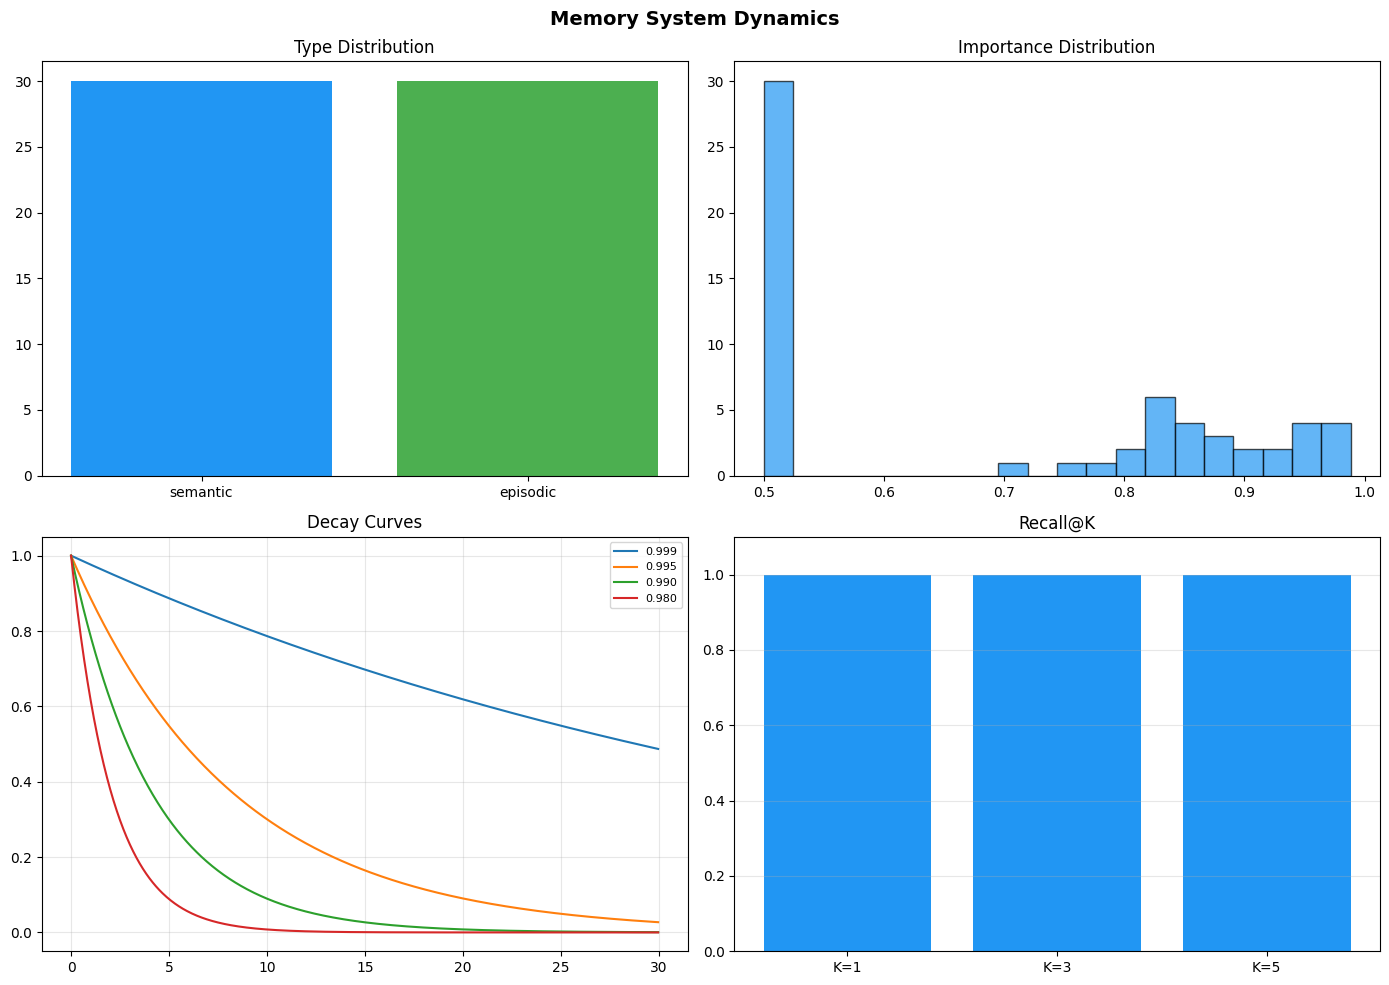

In [ ]:
# ============================================================
# Evaluation + Plots
# ============================================================


def gen_data(ne=15, nf=2, nep=30):
    names = [f"Person_{i}" for i in range(ne)]
    cos = [f"Company_{i}" for i in range(ne // 2)]
    mems, gt, qs = [], {}, []
    for i, n in enumerate(names):
        co = cos[i % len(cos)]
        gt[n] = co
        for f in [f"{n} works at {co} as engineer", f"{n} expertise deep learning"][
            :nf
        ]:
            ents = [n] + ([co] if co in f else [])
            mems.append(
                MemoryEntry(
                    content=f,
                    memory_type="semantic",
                    entities=ents,
                    importance=0.7 + np.random.random() * 0.3,
                )
            )
    for i in range(nep):
        n = names[i % len(names)]
        mems.append(
            MemoryEntry(
                content=f"Day {i}: {n} from {gt[n]} discussed goals",
                memory_type="episodic",
                entities=[n, gt[n]],
                importance=0.5,
            )
        )
    for n in names[:8]:
        qs.append({"q": f"Where does {n} work?", "a": gt[n]})
    return mems, qs


mems, qs = gen_data()
ekg = TempKG()
eret = HybridRetriever(ekg)
all_embs = embed_texts([m.content for m in mems])
for m, emb in zip(mems, all_embs):
    m.embedding = emb
    eret.index(m)
    for e in m.entities:
        ekg.add_node(e, "person" if "Person" in e else "company")

metrics = {}
for k in [1, 3, 5]:
    hits = sum(
        1
        for q in qs
        if any(q["a"].lower() in e.content.lower() for e, _ in eret.search(q["q"], k))
    )
    metrics[f"R@{k}"] = hits / len(qs)
print(f"Generated {len(mems)} memories, {len(qs)} queries")
print("Retrieval:", {k: f"{v:.2f}" for k, v in metrics.items()})

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Memory System Dynamics", fontsize=14, fontweight="bold")
tc = defaultdict(int)
for m in mems:
    tc[m.memory_type] += 1
axes[0, 0].bar(tc.keys(), tc.values(), color=["#2196F3", "#4CAF50"])
axes[0, 0].set_title("Type Distribution")
axes[0, 1].hist(
    [m.importance for m in mems], bins=20, color="#2196F3", alpha=0.7, edgecolor="black"
)
axes[0, 1].set_title("Importance Distribution")
h = np.arange(720)
for l, lam in [("0.999", 0.999), ("0.995", 0.995), ("0.990", 0.990), ("0.980", 0.980)]:
    axes[1, 0].plot(h / 24, lam**h, label=l)
axes[1, 0].set_title("Decay Curves")
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(alpha=0.3)
ks = [1, 3, 5]
axes[1, 1].bar(range(len(ks)), [metrics[f"R@{k}"] for k in ks], color="#2196F3")
axes[1, 1].set_xticks(range(len(ks)))
axes[1, 1].set_xticklabels([f"K={k}" for k in ks])
axes[1, 1].set_title("Recall@K")
axes[1, 1].set_ylim(0, 1.1)
axes[1, 1].grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

# 12) Summary: Architecture Comparison

| Feature | MemGPT/Letta | Mem0 | Zep/Graphiti | GBrain | LLM Wiki | Cognee | LangMem |
|---|---|---|---|---|---|---|---|
| **Metaphor** | OS memory | Universal API | Temporal KG | Self-wiring brain | Wiki | Pipeline | Self-rewriter |
| **Tiers** | Core+buffer+recall+archival | Vector+KV+graph | Episodic+semantic | MD+PG | Sources+wiki | Raw->KG | Prompt versioning |
| **KV store** | No | **Yes** | No | No | No | No | No |
| **Graph** | No | Entity graph | **Full temporal** | Typed links | Wikilinks | **Built from pipeline** | No |
| **Procedural** | Tool defs | No | No | No | No | No | **Self-rewriting** |
| **Doc ingestion** | No | No | No | No | Sources | **Full pipeline** | No |
| **Tool calling** | **Agent decides** | Automatic | Automatic | Automatic | N/A | N/A | Automatic |

**This notebook implements all 7 columns' innovations in a unified system.**